In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import re
import os
from openai import OpenAI

In [5]:
file_path = "_tempavisos.dta"

chunk_size = 10000
chunks = pd.read_stata(file_path, chunksize=chunk_size)

avisos = pd.DataFrame()

for chunk in chunks:
    avisos = pd.concat([avisos, chunk], ignore_index=True)

In [6]:
avisos['avisofechapublicacion'] = pd.to_datetime(avisos['avisofechapublicacion'])

In [7]:
avisos.columns

Index(['avisoid', 'empresaid', 'avisofechapublicacion', 'avisovacante',
       'mostrarsueldo', 'avisoexperiencia', 'expiracion', 'dias',
       'avisorepublicacion', 'avisocargo', 'areanombre',
       'actividadempresanombre', 'avisocuerpo', 'disponibilidadnombre',
       'avisoduracioncont', 'avisolugartrabajo', 'gradoescolarnombre',
       'situacionestudios', 'avisorequisitos', 'carreras', 'estado',
       'endpagado_o_gratuito', 'nivelnombre', 'carreras_array',
       'sueldoestimado', '_merge'],
      dtype='object')

In [8]:
len(avisos['empresaid'].value_counts())

122525

In [9]:
avisos['mes'] = avisos['avisofechapublicacion'].dt.month
avisos['ano'] = avisos['avisofechapublicacion'].dt.year

## Monthly job ads

In [10]:
mensual = avisos.groupby(['mes', 'ano', 'empresaid'])['avisoid'].nunique().reset_index()

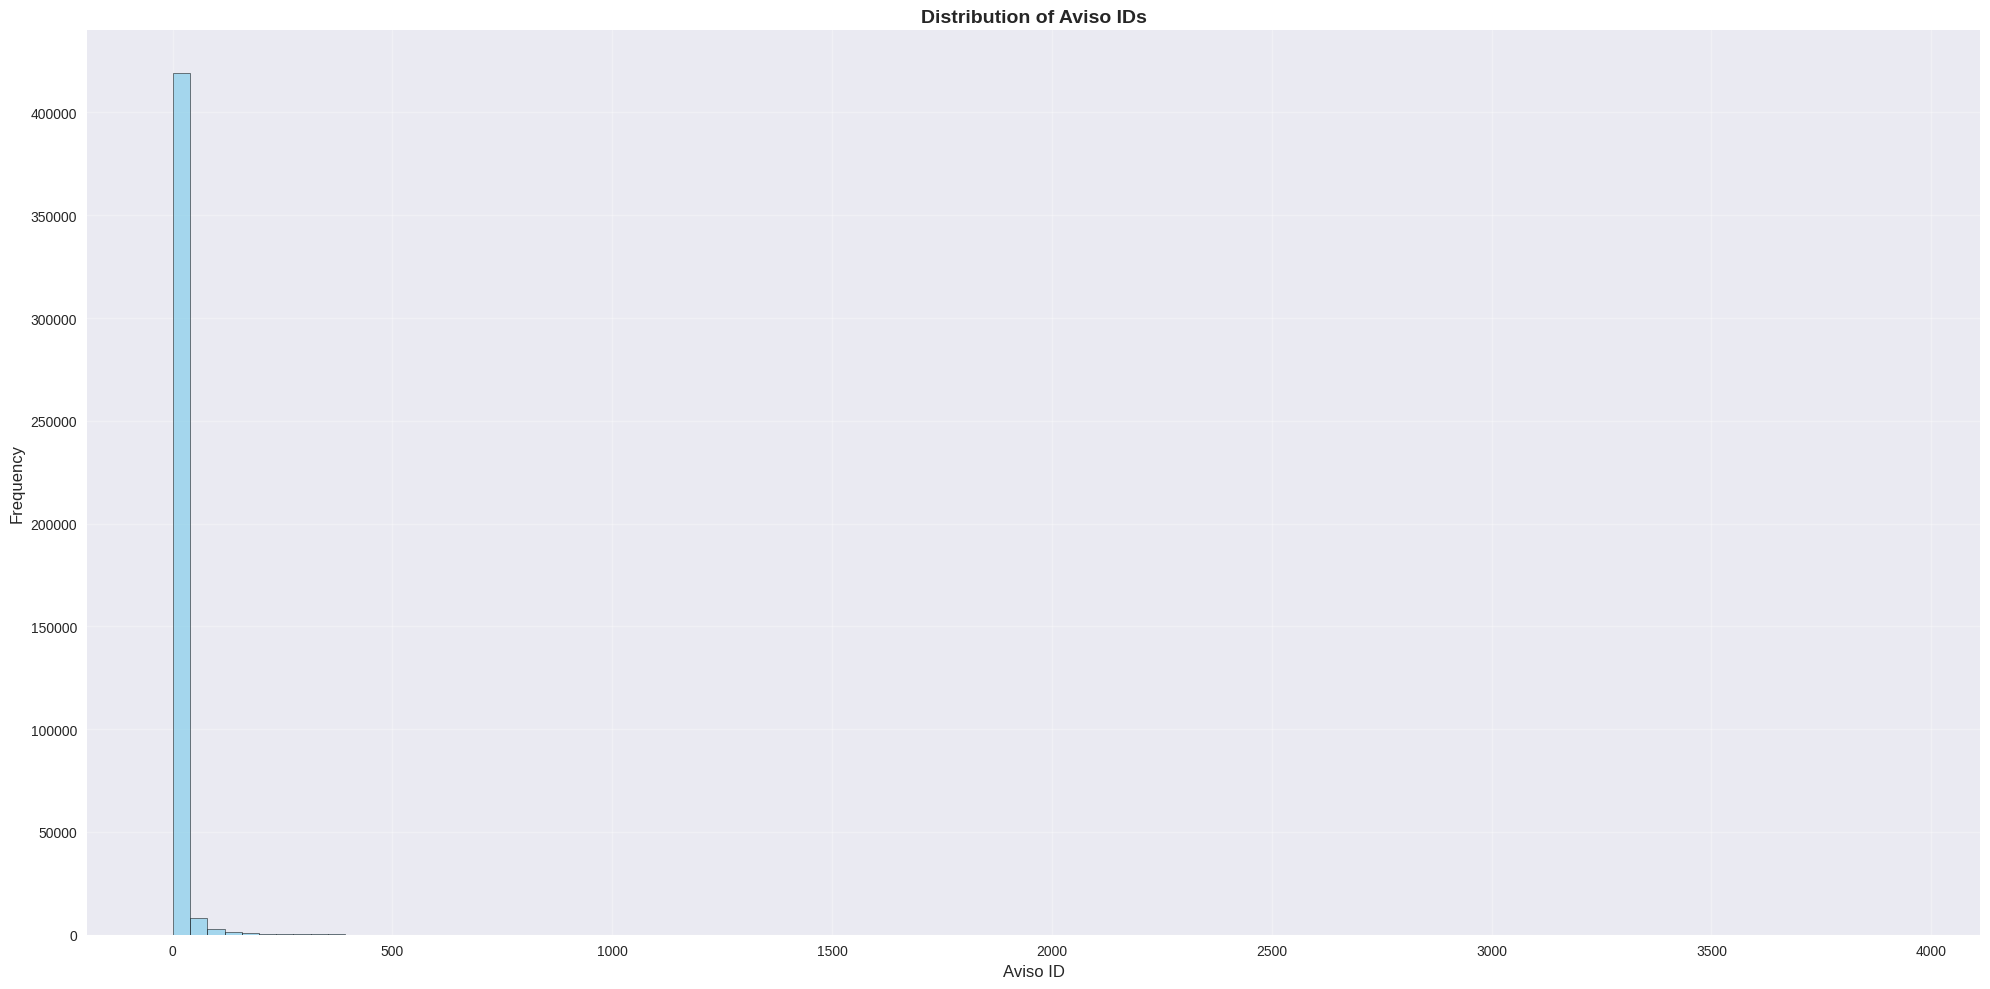

In [11]:
plt.style.use('seaborn-v0_8')

x = mensual['avisoid']

fig, ax = plt.subplots(figsize=(20, 10))

ax.hist(x, bins=100, alpha=0.7, color='skyblue', edgecolor='black', linewidth=0.5)

# Add labels and title
ax.set_xlabel('Aviso ID', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Distribution of Aviso IDs', fontsize=14, fontweight='bold')

# Add grid for better readability
ax.grid(True, alpha=0.3)

# Improve layout
plt.tight_layout()
plt.show()

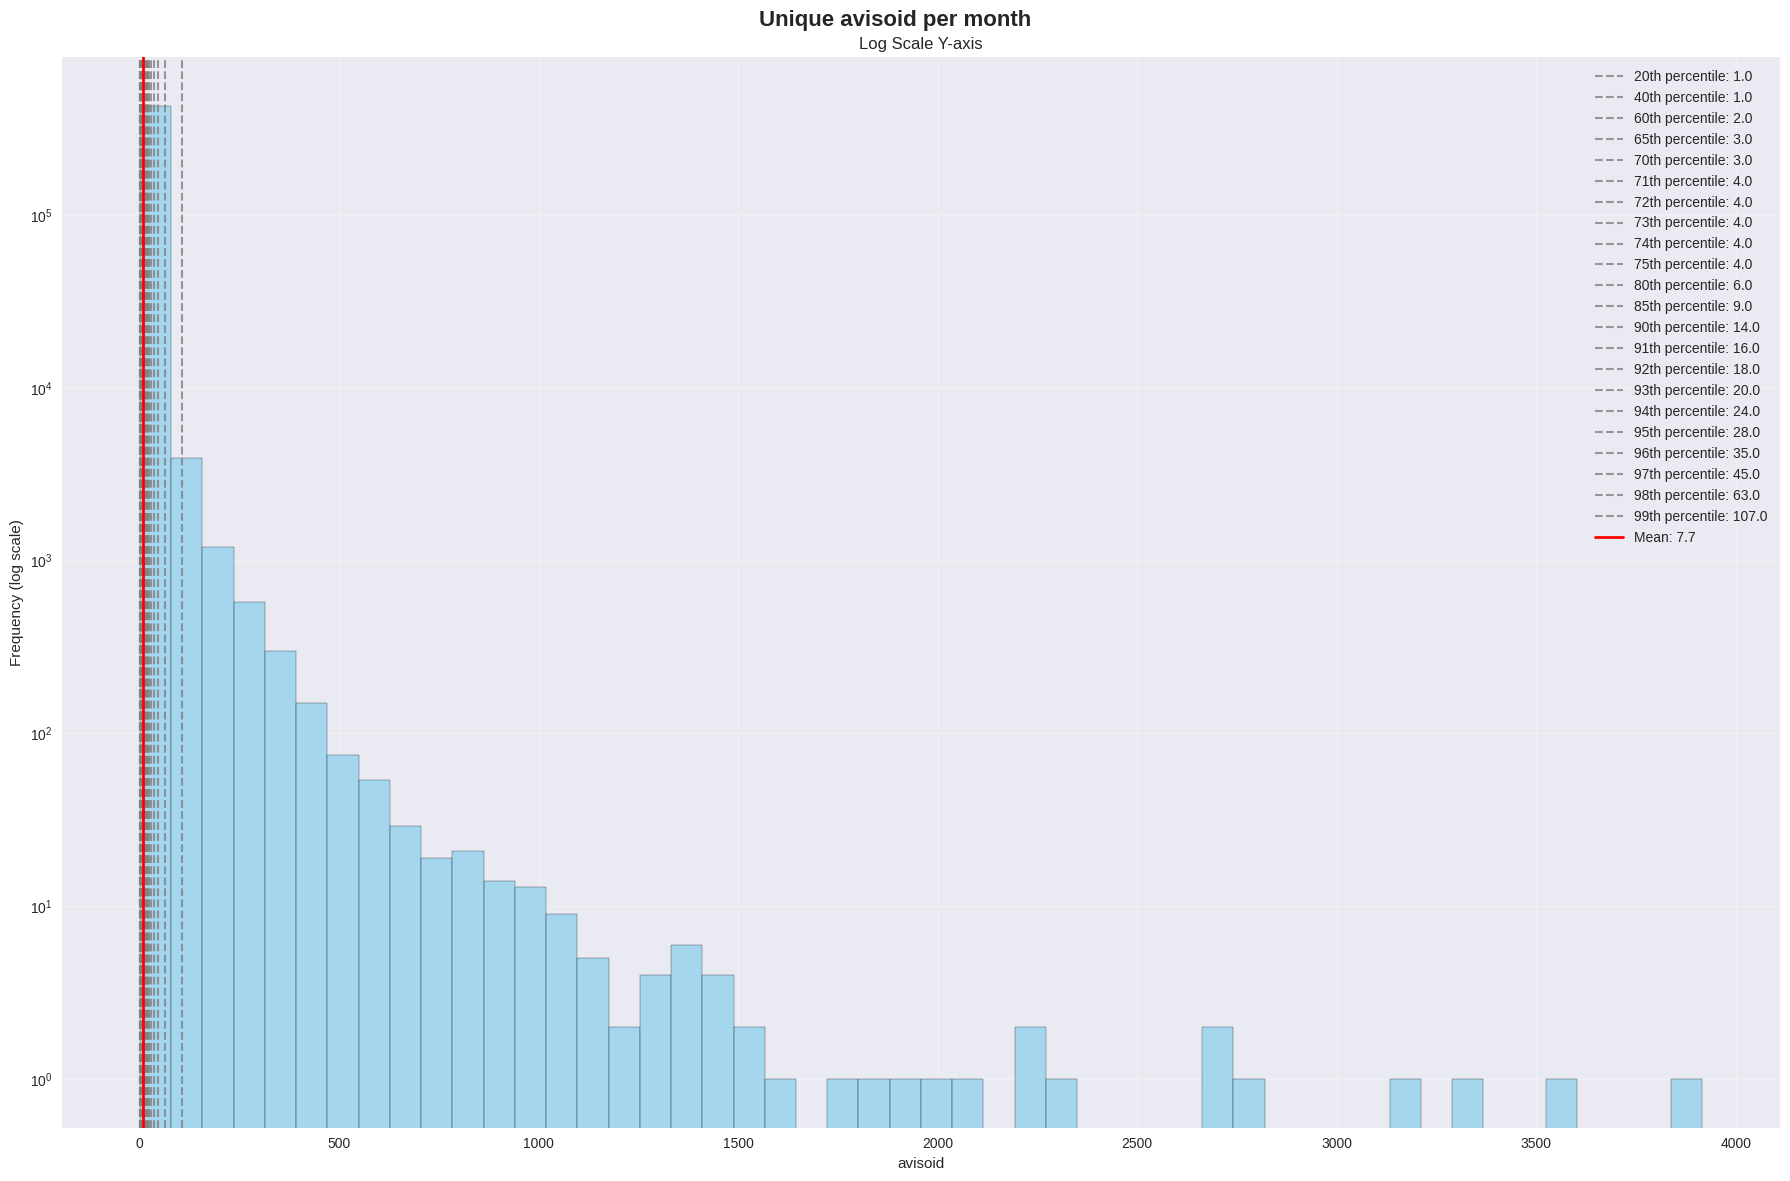

In [12]:
x = mensual['avisoid']

fig, axes = plt.subplots(figsize=(18, 12))
fig.suptitle('Unique avisoid per month', fontsize=16, fontweight='bold')

# Log scale histogram
axes.hist(x, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes.set_yscale('log')
axes.set_title('Log Scale Y-axis')
axes.set_xlabel('avisoid')
axes.set_ylabel('Frequency (log scale)')
axes.grid(True, alpha=0.3)

# Define the percentile values we want to show
percentile_values = [20, 40, 60, 65, 70, 71, 72, 73, 74, 75, 80, 85, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]
percentiles = np.percentile(x, percentile_values)
mean_value = np.mean(x)

# Add vertical lines for percentiles
for i, (pct_val, q) in enumerate(zip(percentile_values, percentiles)):
    axes.axvline(q, color='gray', linestyle='--', alpha=0.8, linewidth=1.5, 
                label=f'{pct_val}th percentile: {q:.1f}')

# Add vertical line for mean in red
axes.axvline(mean_value, color='red', linestyle='-', linewidth=2, 
            label=f'Mean: {mean_value:.1f}')

# Add legend
axes.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

In [13]:
cantidad = 50
print(f"Cantidad de empresas que han publicado más de {cantidad} avisos en un mes: {mensual.loc[mensual['avisoid'] > cantidad]['empresaid'].nunique()}")
print(f"Porcentaje del total de empresas: {mensual.loc[mensual['avisoid'] > cantidad]['empresaid'].nunique()/avisos['empresaid'].nunique()*100}")

Cantidad de empresas que han publicado más de 50 avisos en un mes: 719
Porcentaje del total de empresas: 0.5868190165272393


## Montlhy job ads by firm

In [14]:
empresa_mensual = mensual.groupby('empresaid')['avisoid'].mean().reset_index()

In [15]:
len(empresa_mensual) == avisos['empresaid'].nunique()

True

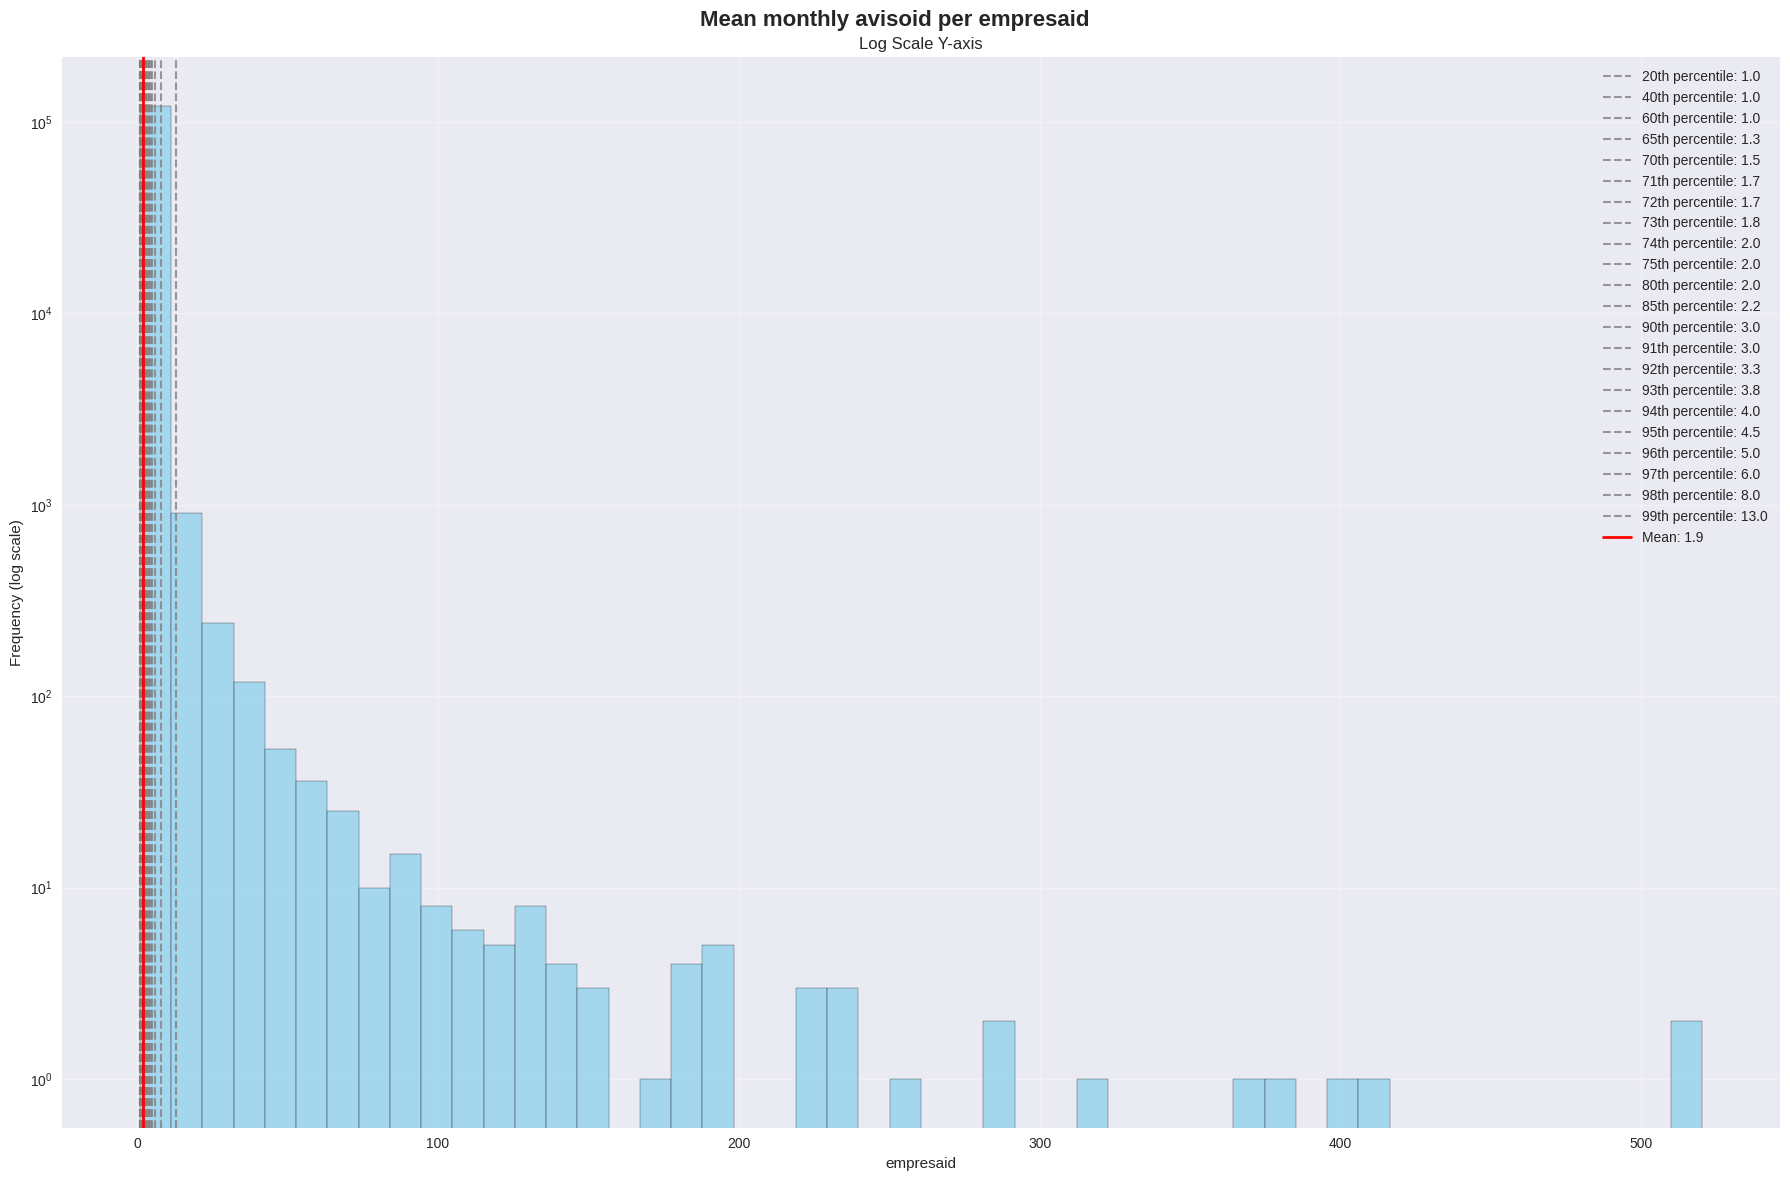

In [16]:
x = empresa_mensual['avisoid']

fig, axes = plt.subplots(figsize=(18, 12))
fig.suptitle('Mean monthly avisoid per empresaid', fontsize=16, fontweight='bold')

# Log scale histogram
axes.hist(x, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes.set_yscale('log')
axes.set_title('Log Scale Y-axis')
axes.set_xlabel('empresaid')
axes.set_ylabel('Frequency (log scale)')
axes.grid(True, alpha=0.3)

# Define the percentile values we want to show
percentile_values = [20, 40, 60, 65, 70, 71, 72, 73, 74, 75, 80, 85, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99]
percentiles = np.percentile(x, percentile_values)
mean_value = np.mean(x)

# Add vertical lines for percentiles
for i, (pct_val, q) in enumerate(zip(percentile_values, percentiles)):
    axes.axvline(q, color='gray', linestyle='--', alpha=0.8, linewidth=1.5, 
                label=f'{pct_val}th percentile: {q:.1f}')

# Add vertical line for mean in red
axes.axvline(mean_value, color='red', linestyle='-', linewidth=2, 
            label=f'Mean: {mean_value:.1f}')

# Add legend
axes.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.show()

In [17]:
cantidad = 50
print(f"Cantidad de empresas con un promedio mensual de publicaciones mayor a {cantidad} avisos en un mes: {empresa_mensual.loc[empresa_mensual['avisoid'] > cantidad]['empresaid'].nunique()}")
print(f"Porcentaje del total de empresas: {empresa_mensual.loc[empresa_mensual['avisoid'] > cantidad]['empresaid'].nunique()/avisos['empresaid'].nunique()*100}")

Cantidad de empresas con un promedio mensual de publicaciones mayor a 50 avisos en un mes: 155
Porcentaje del total de empresas: 0.1265047949398082


In [18]:
empresas = empresa_mensual.loc[empresa_mensual['avisoid'] > cantidad]['empresaid']

In [19]:
rec = avisos.loc[avisos['empresaid'].isin(list(empresas))]

## Ejemplos

### 2203

In [182]:
empresa = 2203

In [183]:
rec.loc[rec['empresaid'] == empresa]['avisocuerpo'].values[0]

'Importante cliente a nivel nacional necesita contratar personal para sus bodegas, ubicadas en sector de San Bernardo, experiencia minima en el cargo similar de a lo menos 1 año, renta ofrecida de $ 160.000 liquidos, horario de trabajo de lunes a viernes de 08:00 a 17:00 hrs y eventualmente los sabados de 08:15 a 12:00 hrs. Interesados Postular a través de esta página e ingresar sus datos a nuestro sitio Web www.xinergia.cl, sección ofertas de trabajo (área administrativa) orden de servicio Nº64159'

In [184]:
rec.loc[rec['empresaid'] == empresa]['avisocuerpo'].values[1]

'PROGRAMADOR  DBA Sql Server 2005\r\nSeptiembre  2008: Se requiere contratar profesional  informático Ingeniero o Analista de Sistemas, para desempeñar el cargo de Analista Programador. Postulantes deben tener conocimiento en SQL Server 2005 - Modelamiento de base de datos (Modelo Lógico y Modelo físico) experiencia en DTS o algun otro metodo para extraer informacion de otras fuentes. Se requiere experiencia laboral de al menos 1 a 2 años. \r\nOfrecemos contrato proyecto de 4 meses.  Interesados actualizar datos indicando disponibilidad.\r\n\r\n\r\nPOSTULA EN LÍNEA A TRAVÉS DE NUESTRA PAGINA WEB HTTP://WWW.XINERGIA.CL/\r\nDONDE DEBES POSTULAR A LA ORDEN DE SERVICIO  64222'

In [185]:
rec.loc[rec['empresaid'] == empresa]['avisocuerpo'].values[2]

'PROGRAMADOR  Whesphere /WebServices\r\nSeptiembre  2008: Se requiere contratar profesional  informático Ingeniero o Analista de Sistemas, para desempeñar el cargo de Analista Programador. Postulantes deben tener conocimiento en Application Server 6.x (experiencia configuración de DataSources, Connection Pool, Queues, Connection Factory, security: realms, conectividad Ms Active Directory) Se requiere experiencia laboral de al menos 3 años.\r\nOfrecemos contrato proyecto de 4 meses.  Interesados actualizar datos indicando disponibilidad.\r\n\r\n\r\nPOSTULA EN LÍNEA A TRAVÉS DE NUESTRA PAGINA WEB HTTP://WWW.XINERGIA.CL/\r\nDONDE DEBES POSTULAR A LA ORDEN DE SERVICIO  64221'

In [186]:
rec.loc[rec['empresaid'] == empresa]['avisocuerpo'].values[3]

'SEPTIEMBRE 2008: Se requiere contratar profesional informático Ingeniero o Técnico informático para desempeñar el cargo de Analista Programador. Postulantes Deben tener conocimientos en Visual Basic, DB2-400 , lenguaje SQL, deseable cobol  400 , Ambiente AS/400, Con experiencia de al menos 2 años en el área. Ofrecemos contrato proyecto de 6 meses. \r\n\r\nInteresados actualizar datos indicando pretensiones de renta y disponibilidad\r\n\r\nPOSTULA EN LÍNEA A TRAVÉS DE NUESTRA PAGINA WEB HTTP://WWW.XINERGIA.CL/\r\nDONDE DEBES POSTULAR A LA ORDEN DE SERVICIO 64218'

### 689389 

In [188]:
empresa = 689389

In [189]:
rec.loc[rec['empresaid'] == empresa]['avisocuerpo'].values[0]

'Caja de Compensación Líder a Nivel Nacional Requiere para Concepción: Supervisores de Recursos Humanos.\r\nDescripción\r\n\r\nRandstad, segunda empresa más grande a nivel mundial en soluciones de recursos humanos, presente en 44 países del mundo y con 4.400 oficinas requiere: Supervisores de Recursos Humanos para la Ciudad de Concepcion.\r\n\r\nObjetivos del Cargo:\r\n- Asumirán la posición de coordinadores y control de las gestiones de recursos humanos de la zona, planificando, controlando y validando la gestión en estas materias.\r\n- Serán el nexo entre la casa matriz, de quiénes recibirán directrices, y la zona donde prestaran servicios, debiendo mantener al día y actualizados los contratos de trabajo, anexos, liquidaciones de renta, entre otras actividades.\r\n- Deberán realizar informes de gestión semanales y contar con disponibilidad para viajar dentro de la zona, visitando las sucursales de la Compañía. (Bono de movilización se rinde).\r\n\r\n'

In [190]:
rec.loc[rec['empresaid'] == empresa]['avisocuerpo'].values[1]

'Randstad, empresa líder a nivel mundial en soluciones de recursos humanos, presente en 44 países del mundo y con 4.400 oficinas requiere: \r\n\r\nJefe de Contabilidad\r\n\r\n\r\nRequisitos:\r\n\r\nContador Auditor\r\n8 años de experiencia minima en el cargo en empresas productivas, comerciales y de servicios.\r\nConocimiento de IFRS\r\nLegislación Tributaria\r\nComercio Exterior\r\nLegislación Laboral\r\nAlgún ERP\r\nExcel Avanzado\r\n\r\nFunciones\r\n\r\n\r\n• Supervisar y analizar información contable.\r\n• Supervisar y coordinar funciones del equipo de trabajo.\r\n• Preparación de estados financieros Mensuales\r\n• Elaboración de renta Liquida.\r\n• Presentación de formularios 29 y declaración anual de renta\r\n• Control de las principales Variables Tributarias\r\n• Preparar y presentar información a entes externos, SII, Tesorería, Ine, etc\r\n• Mantener actualizado el plan y manual de cuentas contables corporativo.\r\n• Generar procedimientos relacionados con el área.\r\n\r\n\r\n\

In [191]:
rec.loc[rec['empresaid'] == empresa]['avisocuerpo'].values[2]

'Randstad Empresa Líder en Recursos humanos a nivel mundial requiere:\r\n\r\nPsicólogo/a enfocada en la ejecución de evaluaciones psicolaborales para la unidad de búsqueda de profesionales. Su principal función es realizar evaluaciones psicológicas de cargos requeridos.\r\n\r\nRequisitos:\r\n\r\nFormación académica de Psicología.\r\nAl menos 2 años de experiencia en evaluaciones psicológicas.\r\nExperiencia en evaluaciones individuales y grupales.\r\nConocimientos de test psicológicos: Lüscher y Zulliger.\r\nPlanificada, Organizada.\r\nResponsable, Comprometida.\r\nOrientada al logro y resultados de los objetivos.\r\n\r\n\r\nRandstad, líder en servicios de recursos humanos, en donde día a día construimos el mundo del trabajo.'

In [192]:
rec.loc[rec['empresaid'] == empresa]['avisocuerpo'].values[3]

'Randstad, empresa líder a nivel mundial en soluciones de recursos humanos, presente en 44 países del mundo y con 4.400 oficinas requiere: Ejecutivo de Negocios Senior para Concepción\r\nContar con estudios tecnicos o superiores \r\nExperiencia Mínima de 1 año en Empresas comerciales.\r\nExperiencia y conocimiento del mercado y de la Industria\r\nConocimientos en normas de calidad\r\nManejo de Microsoft Office a nivel Intermedio.\r\nDisponibilidad para viajar dentro de la Zona Sur.\r\n\r\nOtras competencias:\r\nCapacidad de planificacion y organizacion\r\nCapacidad para formar equipos de trabajo.\r\nAlta tolerancia a la frustración\r\nOrientación a la tarea\r\nCapacidad de trabajo bajo presión\r\nAlto enfoque comercial.\r\n\r\nObjetivos del cargo: \r\nGestión Comercial. \r\nEnfoque en trabajar para cubrir las necesidades en tiempo y forma de sus empresas-clientes.\r\nCumplimiento de presupuestos de ventas y cobertura de zona\r\n\r\nLo que ofrecemos:\r\nPosibilidades de crecimiento prof

### 7383

In [193]:
empresa = 7383

In [194]:
rec.loc[rec['empresaid'] == empresa]['avisocuerpo'].values[0]

'Se requiere a Jefe de Especialidades para hacerse cargo de la intalación y puesta de los sistemas de Climatización, en nuevo Centro Comercial'

In [195]:
rec.loc[rec['empresaid'] == empresa]['avisocuerpo'].values[1]

'Inducir a alumnos de las carrera de ingeniería civil en computación, ejecución o informatica y que se encuentren cursando el último año de carrera  o estén recién egresados, con el fin de entrenarlo- en al menos dos áreas de la organización -por un período máximo de un año. La finalidad es descubrir las potencialidades que posee el candidato para integrarlo a la Corporación, en la medida que esto sea posible.'

In [196]:
rec.loc[rec['empresaid'] == empresa]['avisocuerpo'].values[2]

'GNL Quintero requirere capacitado y con motivación por ser parte del nuevo desafío de la compañía. El proyecto constituye importante oportunidad para Chile, ya que representa una forma de garantizar la autonomía energética del país a través de la diversificación de nuestra matriz energética. El proyecto ya se encuentra en su etapa de construcción y consta de un muelle de más de 1300 metros que permitirá el desembarque de GNL y estanques de gran magnitud para el almacenamiento y regasificación del producto. Debido a la crisis energética y la magnitud del proyecto, las oportunidades laborales se presentan como atractivas ofertas para cualquier profesional que guste de los desafíos.    El Supervisor de Operaciones será responsable de la puesta en marcha de las operaciones de la planta y de la operación segura de todos los sistemas y equipos de esta y su ejecutivo en las instalaciones.    Sus principales funciones son:    -Ser el responsable de la continuidad, eficiencia, seguridad y la f

In [197]:
rec.loc[rec['empresaid'] == empresa]['avisocuerpo'].values[3]

'Importante empresa requiere contratar a Electromecánicos para proyecto en el Aeropuerto Arturo Merino Benítez. Interesante nivel de renta.'

### 37044

In [198]:
empresa = 37044

In [199]:
rec.loc[rec['empresaid'] == empresa]['avisocuerpo'].values[0]

'Buscamos jóvenes profesionales de la carrera de comunicación y Relaciones Públicas.\r\n\r\nSe ofrece integar una importante Compañía multinacional con reales proyecciones.'

In [200]:
rec.loc[rec['empresaid'] == empresa]['avisocuerpo'].values[1]

'Clínica Isapre en pleno crecimiento requiere con urgencia asistentes dentales para sus centros clínicos de la RM'

In [201]:
rec.loc[rec['empresaid'] == empresa]['avisocuerpo'].values[2]

'SE NECESITAN ASISTENTES DENTALES URGENTE PARA NUEVA CLINICA DENTAL EN PUERTO MONTT.'

In [202]:
rec.loc[rec['empresaid'] == empresa]['avisocuerpo'].values[3]

'SE NECESITAN PROMOTORES Y CAPTADORES PARA PROMOCION Y DE NUEVA CLINICA DENTAL EN PUERTO MONTT'

## Looking for the firm's name

In [21]:
rec.columns

Index(['avisoid', 'empresaid', 'avisofechapublicacion', 'avisovacante',
       'mostrarsueldo', 'avisoexperiencia', 'expiracion', 'dias',
       'avisorepublicacion', 'avisocargo', 'areanombre',
       'actividadempresanombre', 'avisocuerpo', 'disponibilidadnombre',
       'avisoduracioncont', 'avisolugartrabajo', 'gradoescolarnombre',
       'situacionestudios', 'avisorequisitos', 'carreras', 'estado',
       'endpagado_o_gratuito', 'nivelnombre', 'carreras_array',
       'sueldoestimado', '_merge', 'mes', 'ano'],
      dtype='object')

In [22]:
rec['aviso'] = rec[['avisocargo', 'avisocuerpo', 'disponibilidadnombre', 'avisorequisitos', 'avisolugartrabajo']].apply(
    lambda row: ' '.join(row.dropna().astype(str)), axis=1
)

/tmp/ipykernel_42237/2512452262.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rec['aviso'] = rec[['avisocargo', 'avisocuerpo', 'disponibilidadnombre', 'avisorequisitos', 'avisolugartrabajo']].apply(


In [36]:
# Function to clean HTML tags
def remove_html_tags(text):
    if pd.isnull(text):
        return ""
    clean = re.compile('<.*?>')
    return re.sub(clean, '', text)

# Clean and count words
rec['aviso'] = rec['aviso'].apply(remove_html_tags)

/tmp/ipykernel_38866/3114940076.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  rec['aviso'] = rec['aviso'].apply(remove_html_tags)


In [47]:
reclutadoras = rec.groupby('empresaid')['aviso'].first().reset_index()

### Pregunta IA

In [48]:
from dotenv import load_dotenv

load_dotenv()

client = OpenAI(api_key=os.environ.get('DEEPSEEK_API_KEY'), base_url="https://api.deepseek.com")

In [49]:
prompt = """Eres un modelo de extracción de información. Tarea:
Dado el texto de un anuncio de empleo, decide si fue publicado por una agencia/reclutadora (intermediaria) y extrae nombres. Devuelve únicamente un arreglo JSON con:
[is_recruiter:boolean, recruiter_name|null, firm_name|null]

Lineamientos:
- is_recruiter = true si quien publica es una agencia de staffing/reclutamiento/selección/outsourcing o un intermediario (p. ej., “estamos contratando para nuestro cliente”, “en nombre de nuestro cliente”, “cliente confidencial”, “para una empresa líder”, “nuestro cliente”, “reclutador de terceros”, “socio de staffing”).
- is_recruiter = false si el anuncio proviene claramente del empleador directo.
- recruiter_name: extrae el nombre de la agencia/publicador (p. ej., “Randstad”, “Adecco”, “XYZ Recruiting”). Si parece un portal de empleo (Indeed, LinkedIn, etc.) pero no actúa como el publicador/intermediario, usa null.
- firm_name: extrae el nombre de la empresa real que contrata cuando esté explícito (p. ej., “contratando para Acme Corp”). Si está anonimizado (“cliente confidencial”, “empresa Fortune 500”, “banco líder”), usa null.
- Prefiere enunciados explícitos sobre conjeturas. No infieras por pistas de industria. Si es ambiguo o contradictorio, usa null.
- Normaliza espacios en blanco, conserva mayúsculas/tildes tal como aparezcan en el anuncio y devuelve exactamente tres campos. Sin texto adicional.

Entrada (ejemplo de formato de usuario):
\"\"\"{TEXTO_DEL_ANUNCIO}\"\"\"

Devuelve únicamente el arreglo JSON en una sola línea, sin formateo ni texto adicional."""

In [50]:
def pregunta(prompt, aviso):
    response = client.chat.completions.create(
        model="deepseek-chat",
        messages=[
            {"role": "system", "content": prompt},
            {"role": "user", "content": aviso},
        ],
        stream=False
    )

    return response.choices[0].message.content

In [52]:
reclutadoras['respuesta'] = reclutadoras['aviso'].apply(lambda aviso: pregunta(prompt, aviso))

In [81]:
reclutadoras['reclu'] = reclutadoras['respuesta'].apply(lambda x: x.split(',')[0][1:])
reclutadoras['nombre empresa'] = reclutadoras['respuesta'].apply(lambda x: x.split(',')[2][:-1])
reclutadoras['nombre reclu'] = reclutadoras['respuesta'].apply(lambda x: x.split(',')[1])

In [83]:
reclutadoras.loc[reclutadoras['reclu'] == "true"]

,empresaid,aviso,respuesta,reclu,nombre reclu,nombre empresa
7,2203,AUXILIAR DE BODEGA (SAN BERNARDO) Importante c...,"[true,""Xinergia"",null]",true,"""Xinergia""",null
8,2286,EJECUTIVA COBRANZA CALL CENTER Estamos buscand...,"[true, null, ""casa de estudios superiores""]",true,null,"""casa de estudios superiores"""
14,4947,"Auxiliar de Tramites Importante Consultora, re...","[true, ""Importante Consultora"", null]",true,"""Importante Consultora""",null
94,660527,Coordinador Gestión Técnica Importante Consult...,"[true, ""Importante Consultora Ingeniería"", null]",true,"""Importante Consultora Ingeniería""",null
96,664984,COD. 547 Gestor de Incidentes Para importante ...,"[true,""Helpnet"",null]",true,"""Helpnet""",null
98,668482,Psicóloga/o Reclutamiento y Selección Consulto...,"[true,""Consultora de Recursos Humanos"",null]",true,"""Consultora de Recursos Humanos""",null
99,668714,Egresados Comercio Exterior / Negocios Interna...,"[true, null, null]",true,null,null
106,689389,Supervisor de Recursos Humanos Caja de Compen...,"[true, ""Randstad"", ""Caja de Compensación Líder...",true,"""Randstad""","""Caja de Compensación Líder a Nivel Nacional"""
113,715138,"Jefe de Planta Nuestro cliente, importante cli...","[true, null, null]",true,null,null
115,725427,Exclusiva tienda argentina PRUNE necesita VEND...,"[true, ""BVM Consultores"", ""PRUNE""]",true,"""BVM Consultores""","""PRUNE"""


In [ ]:
len(rec)/150*0.01

84.69906666666667

In [ ]:
150 = 0.01